In [1]:
# Hücre 1: Gerekli Paketleri Yükle
!pip install numpy pandas scikit-learn tensorflow matplotlib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Hücre 2: Kütüphaneleri İçeri Aktar
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Conv1D, MaxPooling1D, Flatten, LSTM, BatchNormalization
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix

In [3]:
# Hücre 3: Veri Yükleme ve Hazırlama
veri = pd.read_csv("creditcard.csv")

# Etiket sütununu belirleme
labels = veri['Class'].values
nb_classes = len(np.unique(labels))

# Özellik verilerinden etiketin (Class) düşürülmesi
X = veri.drop(['Class'], axis=1)

# Verilerin standartlaştırılması
scaler = StandardScaler().fit(X.values)
X_scaled = scaler.transform(X.values)

# Eğitim ve doğrulama verilerinin ayrılması
X_train, X_valid, y_train, y_valid = train_test_split(X_scaled, labels, test_size=0.3, random_state=42, stratify=labels)

# Çıktı değerlerinin kategorilestirilmesi
y_train_cat = to_categorical(y_train, num_classes=nb_classes)
y_valid_cat = to_categorical(y_valid, num_classes=nb_classes)

# Girdi verilerinin CNNLSTM yapısına uygun yeniden boyutlandırılması
nb_features = X_train.shape[1]

X_train = np.array(X_train).reshape(X_train.shape[0], nb_features, 1)
X_valid = np.array(X_valid).reshape(X_valid.shape[0], nb_features, 1)

print(f"Eğitim Verisi Boyutu: {X_train.shape}")
print(f"Doğrulama Verisi Boyutu: {X_valid.shape}")

Eğitim Verisi Boyutu: (199364, 30, 1)
Doğrulama Verisi Boyutu: (85443, 30, 1)


In [4]:
# Hücre 4: Model Oluşturma ve Derleme
model = Sequential()

# CNN Katmanları
model.add(Conv1D(512, 1, input_shape=(nb_features, 1)))
model.add(Activation("relu"))
model.add(MaxPooling1D(2))
model.add(Conv1D(256, 1))
model.add(Activation("relu"))
model.add(MaxPooling1D(2))

# LSTM ve Yoğun Katmanlar
model.add(LSTM(512))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(Flatten())
model.add(Dropout(0.15))
model.add(Dense(2048, activation="relu"))
model.add(Dense(1024, activation="relu"))

# Çıkış Katmanı (2 sınıf)
model.add(Dense(nb_classes, activation="softmax"))

model.summary()

# Modelin derlenmesi
model.compile(loss="categorical_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

c:\Users\Zeynel\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 512)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 256)        │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 15, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 512)            │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │     1,050,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,860,162 (18.54 MB)

 Trainable params: 4,859,138 (18.54 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [5]:
# Hücre 5: Modelin Eğitilmesi
# Not: Yüksek epoch sayısı (250) yerine düşük bir değer (10) kullanarak hızlandırıldı.
score = model.fit(X_train, y_train_cat, epochs=10, 
                  validation_data=(X_valid, y_valid_cat),
                  batch_size=256)

# Ortalama değerlerin verilmesi
print(f"Ortalama Doğrulama Kaybı: {np.mean(score.history['val_loss']):.4f}")
print(f"Ortalama Doğrulama Başarımı: {np.mean(score.history['val_accuracy']):.4f}")

Epoch 1/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 92s 117ms/step - accuracy: 0.9978 - loss: 0.0092 - val_accuracy: 0.9989 - val_loss: 0.0056
Epoch 2/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 92s 118ms/step - accuracy: 0.9992 - loss: 0.0043 - val_accuracy: 0.9976 - val_loss: 0.0115
Epoch 3/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.9992 - loss: 0.0041 - val_accuracy: 0.9976 - val_loss: 0.0078
Epoch 4/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 89s 114ms/step - accuracy: 0.9992 - loss: 0.0039 - val_accuracy: 0.9993 - val_loss: 0.0047
Epoch 5/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 88s 113ms/step - accuracy: 0.9993 - loss: 0.0035 - val_accuracy: 0.9992 - val_loss: 0.0047
Epoch 6/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 87s 112ms/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 0.9992 - val_loss: 0.0053
Epoch 7/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 87s 112ms/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 0.9992 - val_loss: 0.0046
Epoch 8/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 89s 115ms/step - accuracy: 0.9994 - loss: 0

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step

--- Sınıflandırma Raporu (Precision, Recall, F1-Score) ---
                precision    recall  f1-score   support

   Geçerli (0)       1.00      1.00      1.00     85295
Sahtecilik (1)       0.78      0.76      0.77       148

      accuracy                           1.00     85443
     macro avg       0.89      0.88      0.89     85443
  weighted avg       1.00      1.00      1.00     85443


AUC Skoru: 0.9460


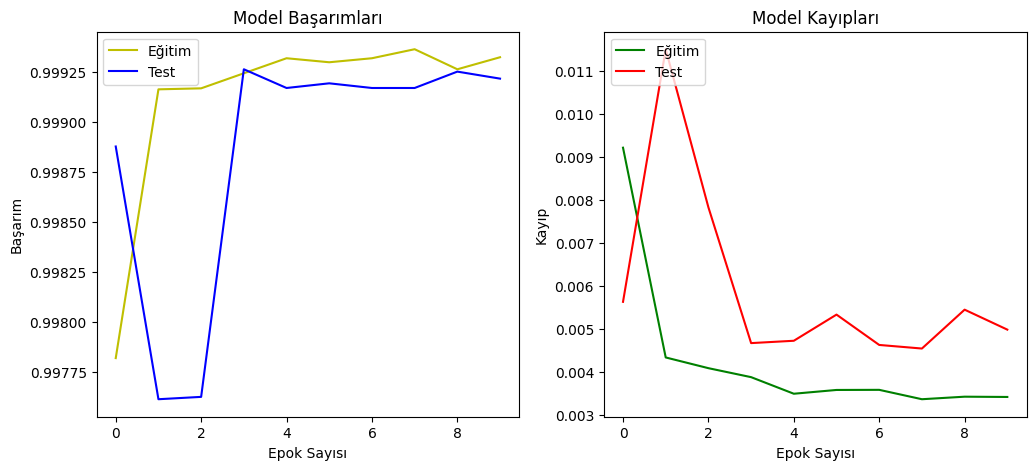

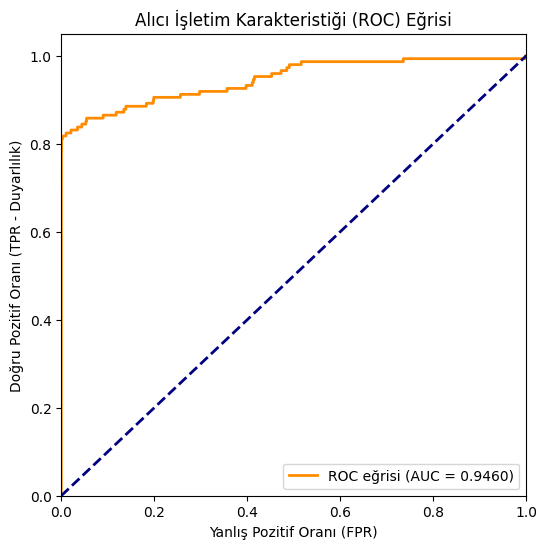

In [6]:
# Hücre 6: Değerlendirme ve Görselleştirme

# Tahminlerin alınması
y_pred_probs = model.predict(X_valid)
y_pred = np.argmax(y_pred_probs, axis=1)

# Sınıflandırma Raporu (F1, Kesinlik, Duyarlılık)
print("\n--- Sınıflandırma Raporu (Precision, Recall, F1-Score) ---")
print(classification_report(y_valid, y_pred, target_names=['Geçerli (0)', 'Sahtecilik (1)']))

# AUC ve ROC Eğrisi için
fpr, tpr, thresholds = roc_curve(y_valid, y_pred_probs[:, 1])
roc_auc = auc(fpr, tpr)
print(f"\nAUC Skoru: {roc_auc:.4f}")


# GRAFİKLER
# Başarım ve Kayıp Grafikleri 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(score.history["accuracy"], color="y", label="Eğitim")
plt.plot(score.history["val_accuracy"], color="b", label="Test")
plt.title("Model Başarımları")
plt.ylabel("Başarım")
plt.xlabel("Epok Sayısı")
plt.legend(loc="upper left")

plt.subplot(1, 2, 2)
plt.plot(score.history["loss"], color="g", label="Eğitim")
plt.plot(score.history["val_loss"], color="r", label="Test")
plt.title("Model Kayıpları")
plt.ylabel("Kayıp")
plt.xlabel("Epok Sayısı")
plt.legend(loc="upper left")
plt.show()

# ROC ve AUC Grafiği 
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC eğrisi (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (FPR)')
plt.ylabel('Doğru Pozitif Oranı (TPR - Duyarlılık)')
plt.title('Alıcı İşletim Karakteristiği (ROC) Eğrisi')
plt.legend(loc="lower right")
plt.show()